# Customer churn predictor for an e-commerce businesses

**Problem Statement**

This project proposes a Customer Churn Prediction and Retention Decision Support System for e-commerce businesses. The system will analyse historical customer purchasing behaviour and predict which customers are likely to churn. In addition to making predictions, the system will provide explanations for each prediction and recommend possible retention strategies, such as personalized discounts, loyalty rewards, targeted marketing campaigns, or product recommendations.

**Group 10**

Ewurakua Amoah 74492028  
    Eyram Fenu 31122028  
    Gabriel Akurang 35882028   
    Nana Asantewaa Osei Bonsu 11782028


In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os




sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   



file = 'E Commerce Dataset.xlsx'


CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


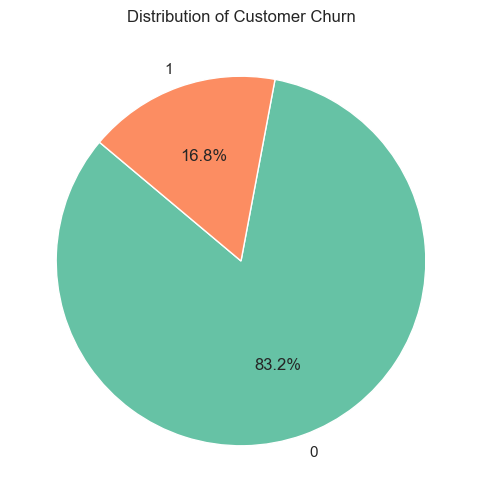

In [3]:
#dataset loaded
e_commerce = pd.read_excel(file, sheet_name="E Comm")

#inspect data
# print(e_commerce.shape)
# print(e_commerce.head())
# print(e_commerce.info())
# print(e_commerce.describe())

# - count missing values per column
print(e_commerce.isna().sum())

#visualize the churn column

churn_counts = e_commerce['Churn'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(churn_counts)],
    startangle=140
)

plt.title('Distribution of Customer Churn')
plt.show()

# 3. Data Preprocessing

## 3.1 Duplicate Records

Duplicate records occur when the same observation appears more than once in the dataset. If left untreated, duplicate records can bias a machine learning model by giving certain observations more influence than others. Therefore, the dataset is first checked for duplicate entries before proceeding with further preprocessing.

In [4]:
# Check for duplicate rows
duplicate_count = e_commerce.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Observation

The dataset contains **0 duplicate records**, indicating that each customer is represented by a unique observation. Therefore, no duplicate rows were removed, and the dataset can proceed to the next preprocessing stage without modification.

Duplicate records can bias machine learning models by causing certain observations to be overrepresented during training. Since no duplicates were detected, this issue does not affect the current dataset.

## 3.2 Missing Values

Missing values are common in real-world datasets and may arise due to incomplete data collection, human error, or system limitations. Most machine learning algorithms cannot handle missing values directly, making it necessary to identify and treat them before model training.

In this section, the dataset is examined for missing values, after which an appropriate imputation strategy will be selected based on the nature of each variable.

In [5]:
# Count missing values in each column
missing_values = e_commerce.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(e_commerce)) * 100

# Combine into one table
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display only columns with missing values
missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Percentage (%)
Tenure,264,4.689165
WarehouseToHome,251,4.458259
HourSpendOnApp,255,4.529307
OrderAmountHikeFromlastYear,265,4.706927
CouponUsed,256,4.547069
OrderCount,258,4.582593
DaySinceLastOrder,307,5.452931


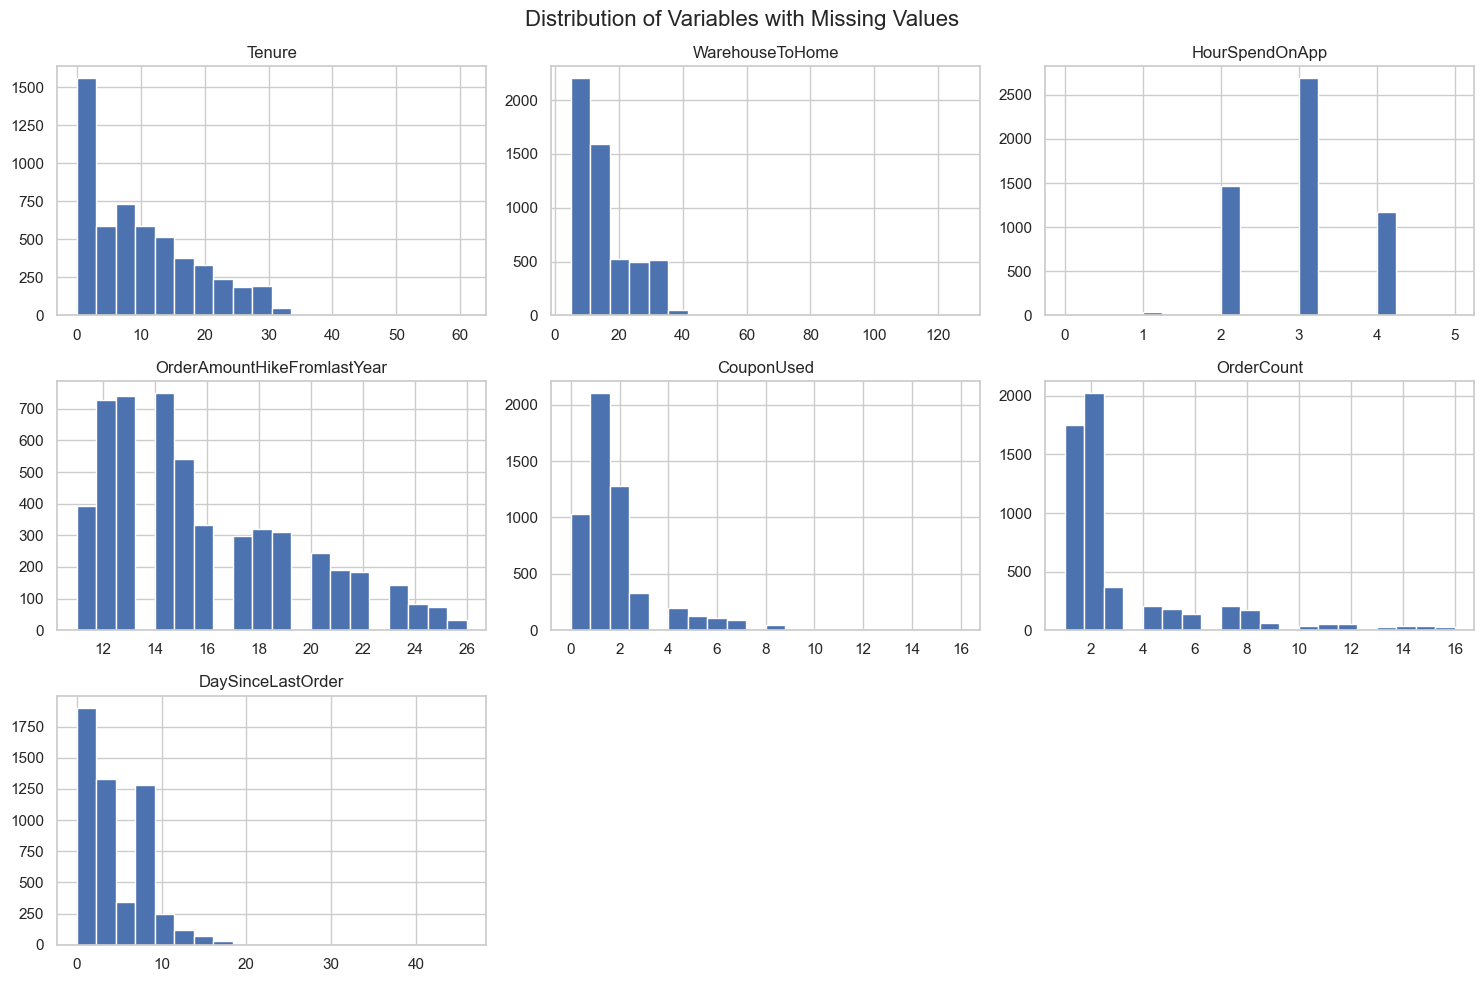

In [6]:
# Visualize the distributions of columns with missing values

columns_with_missing = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]

e_commerce[columns_with_missing].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Variables with Missing Values", fontsize=16)
plt.tight_layout()

plt.show()

In [7]:
# Check skewness

e_commerce[columns_with_missing].skew().sort_values()

HourSpendOnApp                -0.027213
Tenure                         0.736513
OrderAmountHikeFromlastYear    0.790785
DaySinceLastOrder              1.191000
WarehouseToHome                1.619154
OrderCount                     2.196414
CouponUsed                     2.545653
dtype: float64

### Observation

The missing values account for approximately **4–5%** of the dataset across seven numerical variables. Since the proportion of missing data is relatively small, removing these records would unnecessarily reduce the amount of training data available.

To determine the most appropriate imputation method, the distributions and skewness of the affected variables were examined. The results indicate that **HourSpendOnApp** is approximately normally distributed (skewness ≈ -0.03), while the remaining variables exhibit moderate to high positive skewness.

Therefore, the **mean** was used to impute missing values in *HourSpendOnApp*, whereas the **median** was used for all other variables because it is more robust to skewed distributions and outliers.

In [9]:
# Mean imputation for the approximately symmetric variable
e_commerce['HourSpendOnApp'] = e_commerce['HourSpendOnApp'].fillna(
    e_commerce['HourSpendOnApp'].mean()
)

# Median imputation for skewed variables
median_columns = [
    'Tenure',
    'WarehouseToHome',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]

for column in median_columns:
    e_commerce[column] = e_commerce[column].fillna(
        e_commerce[column].median()
    )

In [10]:
# Verify that all missing values have been handled

missing_after = e_commerce.isnull().sum()

print("Total missing values remaining:", missing_after.sum())

missing_after

Total missing values remaining: 0


CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

## 3.3 Data Type Verification

Before training a machine learning model, it is important to verify that every variable has the correct data type. Incorrect data types may lead to unexpected behaviour during preprocessing or model training.

This step confirms that numerical variables are stored as numeric types while categorical variables remain as object types before encoding.

In [11]:
# Display dataset information

e_commerce.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

### Observation

The dataset contains **5,630 observations** and **20 variables**, with no remaining missing values. All variables are stored using appropriate data types. Numerical variables are represented as either integer (`int64`) or floating-point (`float64`) values, while categorical variables are stored as strings.

Since the data types correctly reflect the nature of each variable, no type conversions were required before proceeding to the next preprocessing stage.

## 3.4 Removing Irrelevant Features

Some variables serve only as unique identifiers and do not contain meaningful information for predicting customer churn. Including such variables during model training may introduce unnecessary noise because machine learning algorithms may incorrectly interpret identification numbers as meaningful numerical values.

The `CustomerID` column uniquely identifies each customer but does not describe customer behaviour or purchasing patterns. Therefore, it is removed from the dataset before model development.

In [12]:
# Remove CustomerID since it does not contribute to prediction

e_commerce = e_commerce.drop(columns=['CustomerID'])

print("Remaining columns:", e_commerce.shape[1])

Remaining columns: 19


In [ ]:
e_commerce.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')

### Observation

The `CustomerID` column was successfully removed because it functions solely as a unique identifier and does not provide meaningful information for predicting customer churn. Removing this feature reduces unnecessary noise and prevents the model from learning relationships based on arbitrary identification numbers.

In [13]:
# Display unique values for all categorical variables

categorical_columns = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'Gender',
    'PreferedOrderCat',
    'MaritalStatus'
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(e_commerce[column].value_counts())


PreferredLoginDevice
--------------------
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode
--------------------
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
------
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
----------------
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
-------------
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


In [14]:
# Number of unique categories in each categorical feature

for column in categorical_columns:
    print(f"{column}: {e_commerce[column].nunique()} unique values")

PreferredLoginDevice: 3 unique values
PreferredPaymentMode: 7 unique values
Gender: 2 unique values
PreferedOrderCat: 6 unique values
MaritalStatus: 3 unique values


## 3.5 Data Consistency

The `PreferredPaymentMode` column contained abbreviated and full-text versions of the same payment methods. `CC` was treated as `Credit Card`, while `COD` was treated as `Cash on Delivery`.

Standardizing these values prevents the same payment method from being represented as separate categories during one-hot encoding.

In [15]:
# Standardize equivalent payment mode labels
e_commerce['PreferredPaymentMode'] = (
    e_commerce['PreferredPaymentMode']
    .replace({
        'CC': 'Credit Card',
        'COD': 'Cash on Delivery'
    })
)

# Verify the cleaned categories
e_commerce['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

## 3.6 Encoding Categorical Variables

Machine learning algorithms require numerical inputs. Since the categorical variables in this dataset are nominal and have no natural order, one-hot encoding was applied.

The `drop_first=True` option was used to remove one redundant category from each feature and reduce unnecessary duplication.

In [20]:
categorical_columns = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'Gender',
    'PreferedOrderCat',
    'MaritalStatus'
]

e_commerce = pd.get_dummies(
    e_commerce,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Dataset shape after encoding:", e_commerce.shape)
e_commerce.head()


KeyError: "None of [Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',\n       'PreferedOrderCat', 'MaritalStatus'],\n      dtype='str')] are in the [columns]"

In [23]:
print("\nRemaining object columns:")
print(e_commerce.select_dtypes(include=['object', 'string']).columns.tolist())


Remaining object columns:
[]


### Observation

All categorical variables were successfully transformed into numerical features using one-hot encoding. The original categorical columns were replaced with binary indicator variables, and no object-type variables remain in the dataset. The dataset is therefore fully numerical and ready for subsequent machine learning preprocessing.

## Preprocessing Summary

The preprocessing stage prepared the dataset for machine learning by addressing data quality and consistency issues.

The following steps were completed:

- Verified that the dataset contained no duplicate records.
- Identified and imputed missing values using appropriate statistical measures.
- Confirmed that all variables had appropriate data types.
- Removed the `CustomerID` identifier as it does not contribute to churn prediction.
- Standardized inconsistent payment method labels.
- Converted all categorical variables into numerical format using one-hot encoding.

Following preprocessing, the dataset contains no missing values, no remaining categorical string variables, and is ready for feature engineering and model development.